In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
file_path = os.path.expanduser("~/Documents/Research/diagnosis_data.csv")
chunk_size = 10000
n_rows = 500000

data_list = []
chunks_processed = 0

In [3]:
min_age = float('inf')
max_age = float('-inf')
min_total_cost = float('inf')
max_total_cost = float('-inf')

# Read CSV in chunks and process
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # Filter data for relevant columns
    chunk = chunk[(chunk['Age'] >= 0) & (chunk['Total Cost'] >= 0)]  # Ensure valid data
    
    # Track min and max for Age and Total Cost
    min_age = min(min_age, chunk['Age'].min())
    max_age = max(max_age, chunk['Age'].max())
    min_total_cost = min(min_total_cost, chunk['Total Cost'].min())
    max_total_cost = max(max_total_cost, chunk['Total Cost'].max())
    
    chunks_processed += len(chunk)
    if chunks_processed >= n_rows:
        break

# Print the results
print(f"Minimum Age: {min_age}")
print(f"Maximum Age: {max_age}")
print(f"Minimum Total Cost: {min_total_cost}")
print(f"Maximum Total Cost: {max_total_cost}")

Minimum Age: 0
Maximum Age: 90
Minimum Total Cost: 107.0
Maximum Total Cost: 211137.0


In [4]:
mean_age = 0
std_age = 0
mean_total_cost = 0
std_total_cost = 0

# Variables to calculate running mean and std
sum_age = 0
sum_age_sq = 0
sum_total_cost = 0
sum_total_cost_sq = 0
count = 0

# Read CSV in chunks and process
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # Filter data for relevant columns
    chunk = chunk[(chunk['Age'] >= 0) & (chunk['Total Cost'] >= 0)]  # Ensure valid data
    
    # Calculate sum and squared sum for Age and Total Cost
    sum_age += chunk['Age'].sum()
    sum_age_sq += (chunk['Age']**2).sum()
    sum_total_cost += chunk['Total Cost'].sum()
    sum_total_cost_sq += (chunk['Total Cost']**2).sum()
    
    # Increment count of rows processed
    count += len(chunk)

# Calculate mean and standard deviation for Age and Total Cost
mean_age = sum_age / count
std_age = np.sqrt((sum_age_sq / count) - (mean_age**2))

mean_total_cost = sum_total_cost / count
std_total_cost = np.sqrt((sum_total_cost_sq / count) - (mean_total_cost**2))

# Print the results
print(f"Mean Age: {mean_age:.2f}")
print(f"Standard Deviation of Age: {std_age:.2f}")
print(f"Mean Total Cost: {mean_total_cost:.2f}")
print(f"Standard Deviation of Total Cost: {std_total_cost:.2f}")

Mean Age: 39.41
Standard Deviation of Age: 24.34
Mean Total Cost: 2986.63
Standard Deviation of Total Cost: 4371.96


In [5]:
diagnosis_counts = {}
female_counts = {}

# Read CSV in chunks and process
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # Filter valid data
    chunk = chunk[(chunk['Age'] >= 0) & (chunk['Total Cost'] >= 0)]  # Ensure valid data
    
    # Update diagnosis and female counts
    for diagnosis in chunk['Diagnosis'].unique():
        if diagnosis not in diagnosis_counts:
            diagnosis_counts[diagnosis] = 0
            female_counts[diagnosis] = 0
        
        diagnosis_counts[diagnosis] += chunk[chunk['Diagnosis'] == diagnosis].shape[0]
        female_counts[diagnosis] += chunk[(chunk['Diagnosis'] == diagnosis) & (chunk['Female'] == 1)].shape[0]

# Calculate percentage of females in each diagnosis type
female_percentages = {diagnosis: (female_counts[diagnosis] / diagnosis_counts[diagnosis]) * 100
                      for diagnosis in diagnosis_counts}

# Output results
print(f"Total types of Diagnosis: {len(diagnosis_counts)}")
print("Diagnosis Type and Percentage of Female:")
for diagnosis, percentage in female_percentages.items():
    print(f"{diagnosis}: {percentage:.2f}%")

Total types of Diagnosis: 22
Diagnosis Type and Percentage of Female:
RSP: 54.88%
CIR: 51.50%
INJ: 48.27%
DEN: 51.39%
INF: 51.63%
SYM: 59.37%
EAR: 52.55%
DIG: 54.52%
MUS: 55.39%
MBD: 42.87%
GEN: 69.82%
SKN: 49.97%
FAC: 46.57%
END: 53.49%
NVS: 59.10%
PRG: 100.00%
NEO: 54.88%
EXT: 40.93%
BLD: 58.69%
EYE: 51.99%
MAL: 44.20%
PNL: 46.84%


In [6]:
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    chunk = chunk[(chunk['Total Cost'] >= 0) & (chunk['Age'] >= 0)]
    data_list.append(chunk)
    chunks_processed += len(chunk)
    if chunks_processed >= n_rows:
        break

data = pd.concat(data_list, ignore_index=True)

In [7]:
for col in ['Total Cost', 'Age']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    data = data[(data[col] >= (Q1 - 1.5 * IQR)) & (data[col] <= (Q3 + 1.5 * IQR))]

In [8]:
features = ['Age', 'Female', 'Diagnosis', 'ZIP', 'NCHS', 'Pay1']
X = data[features]
y = data['Total Cost']

In [9]:
X = pd.concat([X.drop('Diagnosis', axis=1), pd.get_dummies(X['Diagnosis'], prefix='Diag', drop_first=True)], axis=1)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 614.55
Mean Squared Error (MSE): 683626.06
Root Mean Squared Error (RMSE): 826.82
R² Score: 0.1748


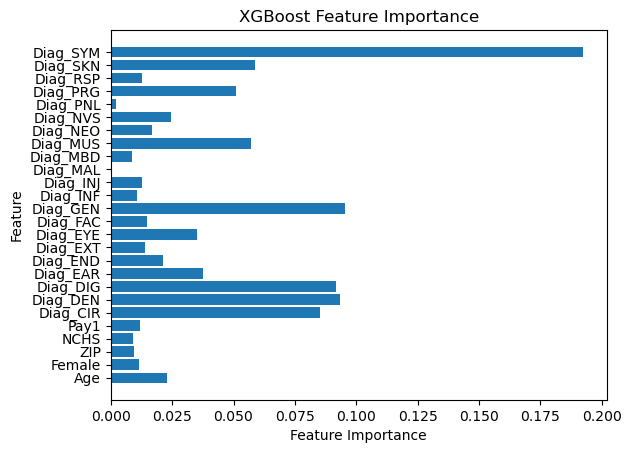

In [13]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get feature importances
feature_importances = model.feature_importances_

# Plot feature importances
plt.barh(X.columns, feature_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()


In [14]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 8],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# Initialize model
model = XGBRegressor(objective='reg:squarederror', random_state=42)

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error', verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters
print(f"Best parameters: {grid_search.best_params_}")

# Use the best model to make predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Fitting 3 folds for each of 2187 candidates, totalling 6561 fits
Best parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.7}
Mean Absolute Error (MAE): 606.85
Mean Squared Error (MSE): 659317.18
Root Mean Squared Error (RMSE): 811.98
R² Score: 0.2041
